# Project 08 - Fine-tuning LLMs with LoRA / QLoRA

**A self-explanatory Kaggle notebook.** Each code cell is explained in plain English above it.

When prompting and RAG aren't enough, you **fine-tune**. But fully fine-tuning a billion-parameter
model needs a cluster. **LoRA** and **QLoRA** let you do it on a *single* GPU. This notebook builds
the two key ideas - **low-rank adapters** and **4-bit quantization** - in plain NumPy so you can
see *why* they work, then gives you the real PEFT/TRL training code for a Kaggle GPU.

**What you'll learn**
- The difference between **full fine-tuning** and **parameter-efficient fine-tuning (PEFT)**.
- **LoRA**: train a tiny low-rank "patch" instead of the whole weight matrix (you'll see the
  parameter savings).
- **Quantization**: store weights in 4 bits to fit big models in small memory (you'll see the
  memory vs error trade-off). **QLoRA** = LoRA on top of a 4-bit model.

## The scenario
You want an LLM that writes support replies in *your company's* exact tone, or translates between
your internal SQL dialect and plain English. Prompting gets you 80% there; to nail it you fine-tune
on a few hundred examples. You have one GPU (Kaggle's free T4). LoRA/QLoRA make that enough.

## Foundations (plain English)
- **Full fine-tuning** updates *every* weight - billions of numbers, huge memory, easy to break.
- **PEFT** freezes the giant pretrained model and trains a *tiny* number of new weights instead.
- **LoRA** is the most popular PEFT method: for a weight matrix W (say 4096x4096), instead of
  learning a full 4096x4096 update, it learns two skinny matrices A (4096 x r) and B (r x 4096)
  with a small **rank** r (like 8). The update is their product `A @ B`. Far fewer numbers, almost
  the same effect - because fine-tuning updates turn out to be approximately **low-rank**.
- **Quantization** stores each weight in fewer bits (4 instead of 32) - 8x less memory - with a
  tiny rounding error.
- **QLoRA** = load the frozen base model in **4-bit** (saves memory) and train **LoRA** adapters
  on top. That's how a big model fine-tunes on one small GPU.

### Cell 1 - imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
rng = np.random.default_rng(0)
print("ready")

ready


### Cell 2 - LoRA's parameter saving (the whole point)
A weight matrix is d x d. Full fine-tuning trains d*d numbers. LoRA trains only 2*d*r. For
d=4096 and r=8 that's millions vs tens of thousands - a ~250x reduction.

In [2]:
d = 4096
print(f"full fine-tune trains: {d*d:,} numbers per matrix")
for r in [4, 8, 16, 32]:
    lora = 2*d*r
    print(f"LoRA r={r:>2}: {lora:,} numbers  ->  {d*d/lora:,.0f}x fewer")

full fine-tune trains: 16,777,216 numbers per matrix
LoRA r= 4: 32,768 numbers  ->  512x fewer
LoRA r= 8: 65,536 numbers  ->  256x fewer
LoRA r=16: 131,072 numbers  ->  128x fewer
LoRA r=32: 262,144 numbers  ->  64x fewer


### Cell 3 - diagram: trainable parameters, full vs LoRA
On a log scale you can see LoRA's bars are a tiny fraction of full fine-tuning. Fewer trainable
numbers = less memory, faster training, and small shippable adapter files (a few MB).

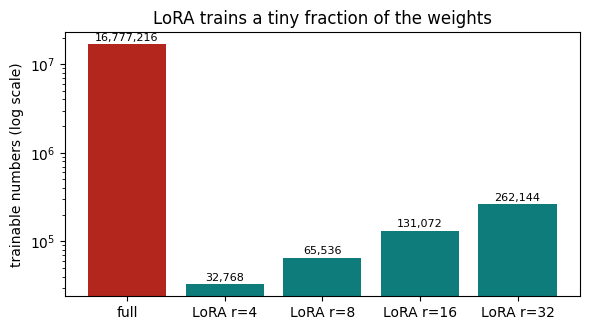

In [3]:
labels = ["full"] + [f"LoRA r={r}" for r in [4,8,16,32]]
vals = [d*d] + [2*d*r for r in [4,8,16,32]]
plt.figure(figsize=(6,3.4))
bars = plt.bar(labels, vals, color=["#b3261e"]+["#0e7c7b"]*4)
plt.yscale("log"); plt.ylabel("trainable numbers (log scale)")
plt.title("LoRA trains a tiny fraction of the weights")
for b,v in zip(bars, vals): plt.text(b.get_x()+b.get_width()/2, v*1.1, f"{v:,}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

### Cell 4 - WHY low rank works: updates are approximately low-rank
We make a target weight-update matrix that is *mostly* low-rank, then approximate it with rank r
(via SVD, which gives the best rank-r approximation). Watch the error collapse with small r - that
is exactly why a low-rank A@B can stand in for a full update.

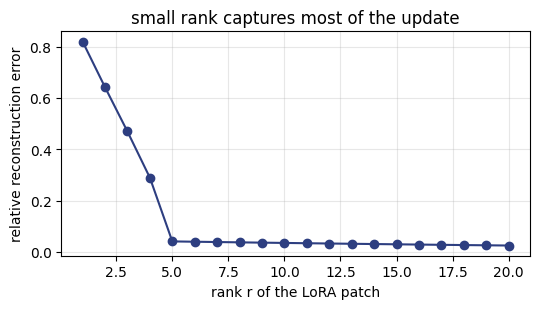

In [4]:
# a 64x64 'true update' that is approximately rank-5 plus a little noise
target = rng.standard_normal((64,5)) @ rng.standard_normal((5,64)) + 0.1*rng.standard_normal((64,64))
def low_rank(M, r):
    U,S,Vt = np.linalg.svd(M, full_matrices=False)
    return (U[:,:r]*S[:r]) @ Vt[:r]
ranks = range(1, 21)
err = [np.linalg.norm(target-low_rank(target,r))/np.linalg.norm(target) for r in ranks]
plt.figure(figsize=(5.5,3.2))
plt.plot(list(ranks), err, "o-", color="#2d3e80")
plt.xlabel("rank r of the LoRA patch"); plt.ylabel("relative reconstruction error")
plt.title("small rank captures most of the update"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Cell 5 - diagram: the update vs its low-rank patch
Left: the full target update. Right: a rank-4 LoRA-style approximation. They look almost the same -
with a fraction of the numbers.

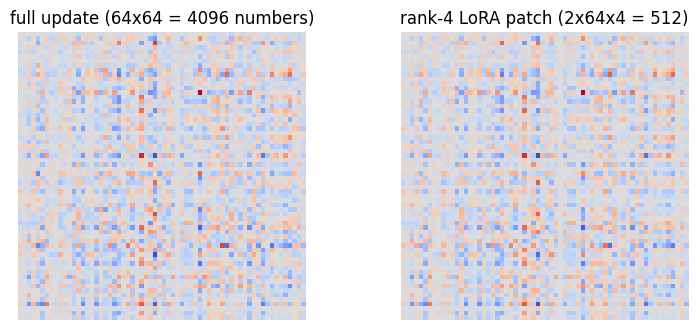

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(8,3.4))
ax[0].imshow(target, cmap="coolwarm"); ax[0].set_title("full update (64x64 = 4096 numbers)")
ax[1].imshow(low_rank(target,4), cmap="coolwarm"); ax[1].set_title("rank-4 LoRA patch (2x64x4 = 512)")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

### Cell 6 - quantization: store weights in 4 bits
QLoRA loads the frozen base model in 4-bit to save memory. We quantize float32 weights to 16
levels (4 bits), then dequantize, and measure the memory saved and the tiny error introduced.

In [6]:
W = rng.standard_normal(20000).astype(np.float32)
def quantize(w, bits=4):
    qmax = 2**bits - 1
    scale = (w.max()-w.min())/qmax
    q = np.round((w - w.min())/scale)            # integers 0..15
    deq = q*scale + w.min()                       # back to float (approx)
    return q, deq, scale
q, deq, scale = quantize(W)
mem32, mem4 = W.nbytes, len(W)*4//8               # bytes at 32-bit vs 4-bit
print(f"memory: fp32 = {mem32:,} bytes  ->  int4 = {mem4:,} bytes  ({mem32/mem4:.0f}x smaller)")
print(f"average rounding error per weight: {np.abs(W-deq).mean():.4f}")

memory: fp32 = 80,000 bytes  ->  int4 = 10,000 bytes  (8x smaller)
average rounding error per weight: 0.1405


### Cell 7 - diagram: what 4-bit quantization does
The histogram shows the original weights; the vertical lines are the 16 allowed 4-bit levels.
Every weight snaps to its nearest line - small error, big memory win.

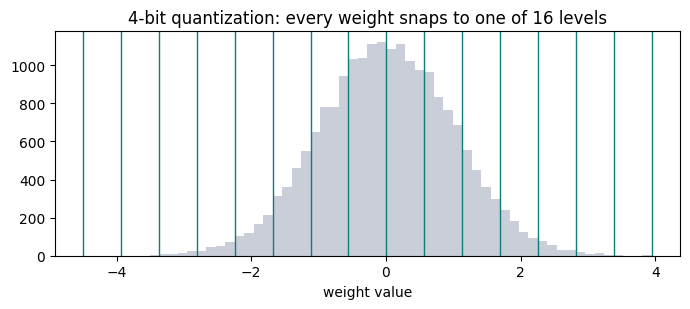

In [7]:
plt.figure(figsize=(7,3.2))
plt.hist(W, bins=60, color="#c9ced9")
for lvl in (np.arange(16)*scale + W.min()):
    plt.axvline(lvl, color="#0e7c7b", lw=1)
plt.title("4-bit quantization: every weight snaps to one of 16 levels")
plt.xlabel("weight value"); plt.tight_layout(); plt.show()

## The real thing - QLoRA fine-tuning on a Kaggle GPU
Load a small open model in 4-bit, attach LoRA adapters, and train with TRL's SFTTrainer. This
fits a multi-billion-parameter model on a single free GPU.

```python
# pip install transformers peft trl bitsandbytes datasets accelerate
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig
from datasets import load_dataset

bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype="bfloat16")            # 4-bit base (the 'Q' in QLoRA)
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B", quantization_config=bnb,
                                             device_map="auto")
tok = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B")

lora = LoraConfig(r=8, lora_alpha=16, target_modules=["q_proj","v_proj"],  # the low-rank patches
                  lora_dropout=0.05, task_type="CAUSAL_LM")

data = load_dataset("json", data_files="train.jsonl")["train"]  # your instruction/response pairs
trainer = SFTTrainer(model=model, train_dataset=data, peft_config=lora,
                     args=SFTConfig(output_dir="out", num_train_epochs=2,
                                    per_device_train_batch_size=4, report_to="wandb"))
trainer.train()
trainer.model.push_to_hub("your-username/my-lora-adapter")   # the adapter is only a few MB
```

**Always** evaluate the fine-tuned model against the base model on a held-out set (task metric +
side-by-side samples). If it didn't beat the base model, the fine-tune wasn't worth it - that's a
real, reportable finding.

## What just happened (recap)
- **LoRA** trains two skinny matrices instead of a full weight update - hundreds of times fewer
  numbers (you saw the bar chart), because updates are approximately **low-rank** (you saw the
  error collapse with small r).
- **4-bit quantization** stores the frozen base model in ~8x less memory with tiny error.
- **QLoRA** = 4-bit base + LoRA adapters = fine-tune a big model on one small GPU.

## Scenarios & your turn
- **Pick the rank:** in Cell 4, where does the error stop improving? That's a good LoRA `r`.
- **Quantization error:** lower `bits` to 2 in Cell 6 - memory drops but error rises. Trade-off!
- **Forgetting:** after fine-tuning, always re-check the model on general tasks (it can 'forget').
- **Project goal:** QLoRA-fine-tune a small open model on your own task, push the adapter to the
  Hugging Face Hub, and show a before/after demo.

## Mini-glossary
**fine-tuning** adapt a pretrained model - **PEFT** train few new weights - **LoRA** low-rank
adapter A@B - **rank (r)** size of the adapter - **quantization** fewer bits per weight - **4-bit /
nf4** a compact weight format - **QLoRA** 4-bit base + LoRA - **adapter** the small trained file -
**catastrophic forgetting** losing general skill after fine-tuning.